In [ ]:
# from aso_workflow.pipeline import ASOAssessmentPipeline

# pipeline = ASOAssessmentPipeline(model_name="claude-sonnet-4-6", llm_only=True, use_web_search=True)
# hgvs = "NM_000350.3:c.2626C>T"
# result = pipeline.run(hgvs, steps_to_run=["variant_check"])
# result

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
NEG_LABELS = ["not_applicable", "not_eligible"]
POS_LABELS = ["likely_eligible", "eligible"]

CATEGORIES = [
    "splice_correction",
    "exon_skipping",
    "transcript_knockdown",
    "wt_upregulation",
]

LABEL_ORDER = [
    "unable_to_assess",
    "not_eligible",
    "unlikely_eligible",
    "likely_eligible",
    "eligible",
]

def parse_outcome_str(outcome_str: str) -> dict:
    """
    Parses labels in form "approach1:label1;approach2:label2" into
    {"approach1": "label1", "approach2": "label2"}

    If a therapy has no label, it is considered "not applicable".
    All therapies are considered "unable to assess" if the outcome_str = "unable to assess".
    """
    parts = outcome_str.split(";")
    parsed = {k:"not_applicable" for k in ["splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]}
    if outcome_str == "unable_to_assess":
        return {k:"unable_to_assess" for k in parsed.keys()}
    for part in parts:
        if ':' in part:
            # add underscores to match the automated pipeline output format
            key, value = part.split(':')
            parsed[key] = value
    
    if "knockdown" in parsed:
        kd = parsed.pop("knockdown")
        parsed["transcript_knockdown"] = kd
    return parsed

def categorize_assessment(row: pd.Series):
    labels = [row[k] for k in ["splice_correction", "exon_skipping", "transcript_knockdown", "wt_upregulation"]]
    if any([lbl in POS_LABELS for lbl in labels]):
        return "positive"
    elif any([lbl in NEG_LABELS for lbl in labels]):
        return "negative"
    return "unable_to_assess"


dataset = pd.read_csv("data/parsed_n1c_assessments.csv")
dataset.drop_duplicates(subset="normalized_hgvs", keep="first", inplace=True)
parsed_outcomes = dataset["parsed_outcome"].apply(lambda x: parse_outcome_str(x)).tolist()

hgvs2outcome = dict(zip(dataset["normalized_hgvs"], parsed_outcomes))
hgvs2metadata = dataset.set_index("normalized_hgvs").drop(columns="parsed_outcome").to_dict(orient="index")

### dataset

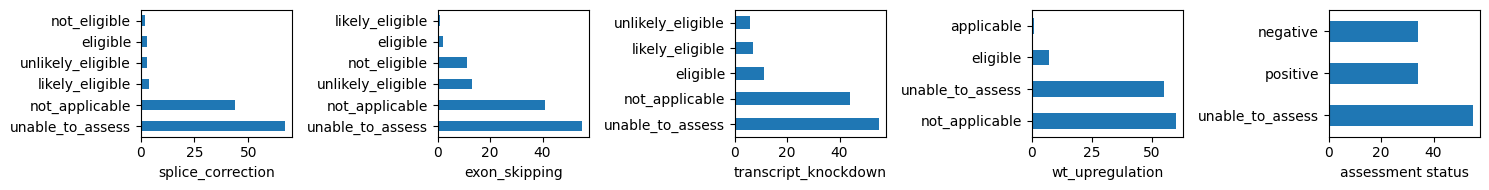

In [3]:
fig, axs = plt.subplots(1, 5, figsize=(15, 2))
true_outcomes_df = pd.DataFrame(parsed_outcomes)
true_outcomes_df["assessment status"] = true_outcomes_df.apply(categorize_assessment, axis=1)

for col,ax in zip(true_outcomes_df.columns, axs.flatten()):
    true_outcomes_df[col].value_counts().plot(kind='barh', ax=ax)
    ax.set_ylabel("")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### report grading

In [8]:
def calculate_score(true_outcome: dict, pred_outcome: dict, strict: bool = False) -> dict:
    """
    Scores a predicted outcome against a true outcome.
    Assumes both `true_outcome` and `pred_outcome` are dictionaries with keys
    "knockdown", "splice_correction", "transcript_knockdown", "wt_upregulation", "exon_skipping".
    """
    # grading scale (4 pt possible):
    # - same label = 1 pt
    # - diff label = 0 pt if strict, or potential partial credit for similar options
    scores = defaultdict(float)
    for k in true_outcome.keys():
        if true_outcome[k] == pred_outcome[k]:
            scores[k] = 1
        # if exact match, stop here
        elif strict:
            scores[k] = 0
        # otherwise, consider partial matches
        elif true_outcome[k] in POS_LABELS and pred_outcome[k] in POS_LABELS:
            scores[k] = 1
        elif true_outcome[k] in NEG_LABELS and pred_outcome[k] in NEG_LABELS:
            scores[k] = 1
        else:
            scores[k] = 0
    return scores


def grade_reports(out_dir: str, strict: bool = False):
    fail_patterns = ["LLM response could not be parsed", "Step failed with error", "✗ Failed"]

    results = []
    labels = []
    for fname in os.listdir(out_dir):
        if not fname.endswith(".json"):
            continue
        out_file = os.path.join(out_dir, fname)
        with open(out_file, "r") as f:
            report = json.load(f)
        report_str = json.dumps(report)
        failed = any([p in report_str for p in fail_patterns])
        true_outcome = hgvs2outcome[report["hgvs"]]
        score_dict = calculate_score(true_outcome, report["predicted_outcome"], strict=strict)
        
        results.append({"hgvs": report["hgvs"], "failed": failed, **score_dict})
        labels.append({
            "hgvs": report["hgvs"],
            "failed": failed,
            "predicted": report["predicted_outcome"],
            "actual": true_outcome,
        })

    results_df = pd.DataFrame(results)
    results_df["overall"] = (
        results_df["splice_correction"] + 
        results_df["exon_skipping"] + 
        results_df["transcript_knockdown"] + 
        results_df["wt_upregulation"]
    ) / 4.0
    labels_df = pd.DataFrame(labels)
    labels_df = _expand_labels(labels_df)
    
    # exclude failures from scores, but report the percent failure
    scores = results_df.loc[~results_df["failed"]].mean(numeric_only=True)
    scores["failed"] = results_df["failed"].sum()
    return scores, labels_df


def _expand_labels(df, pred_col="predicted", actual_col="actual"):
    """Expand prediction/actual JSON columns into a flat dataframe."""
    pred_expanded = df[pred_col].apply(pd.Series)
    actual_expanded = df[actual_col].apply(pd.Series)

    pred_expanded = pred_expanded[CATEGORIES].add_prefix("pred_")
    actual_expanded = actual_expanded[CATEGORIES].add_prefix("actual_")

    metadata = df.drop(columns=[pred_col, actual_col])
    return pd.concat([metadata, pred_expanded, actual_expanded], axis=1)

def plot_confusion_matrices(flat_df):
    """Plot one confusion matrix per category."""
    _, axes = plt.subplots(2, 2, figsize=(16, 14))
    axes = axes.flatten()

    for ax, category in zip(axes, CATEGORIES):
        y_true = flat_df[f"actual_{category}"]
        y_pred = flat_df[f"pred_{category}"]

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=LABEL_ORDER,
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=LABEL_ORDER,
        )
        disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
        ax.set_title(category.replace("_", " ").title())

    plt.tight_layout()
    plt.show()

In [6]:
scores, labels_df = grade_reports("outputs/gpt-5")
# scores, labels_df = grade_reports("outputs/gpt-5__llm-only__web-search")
print(scores)

failed                  0.000
splice_correction       0.500
exon_skipping           0.900
transcript_knockdown    0.700
wt_upregulation         0.800
overall                 0.725
dtype: float64


total examples: 10
total examples without error: 10


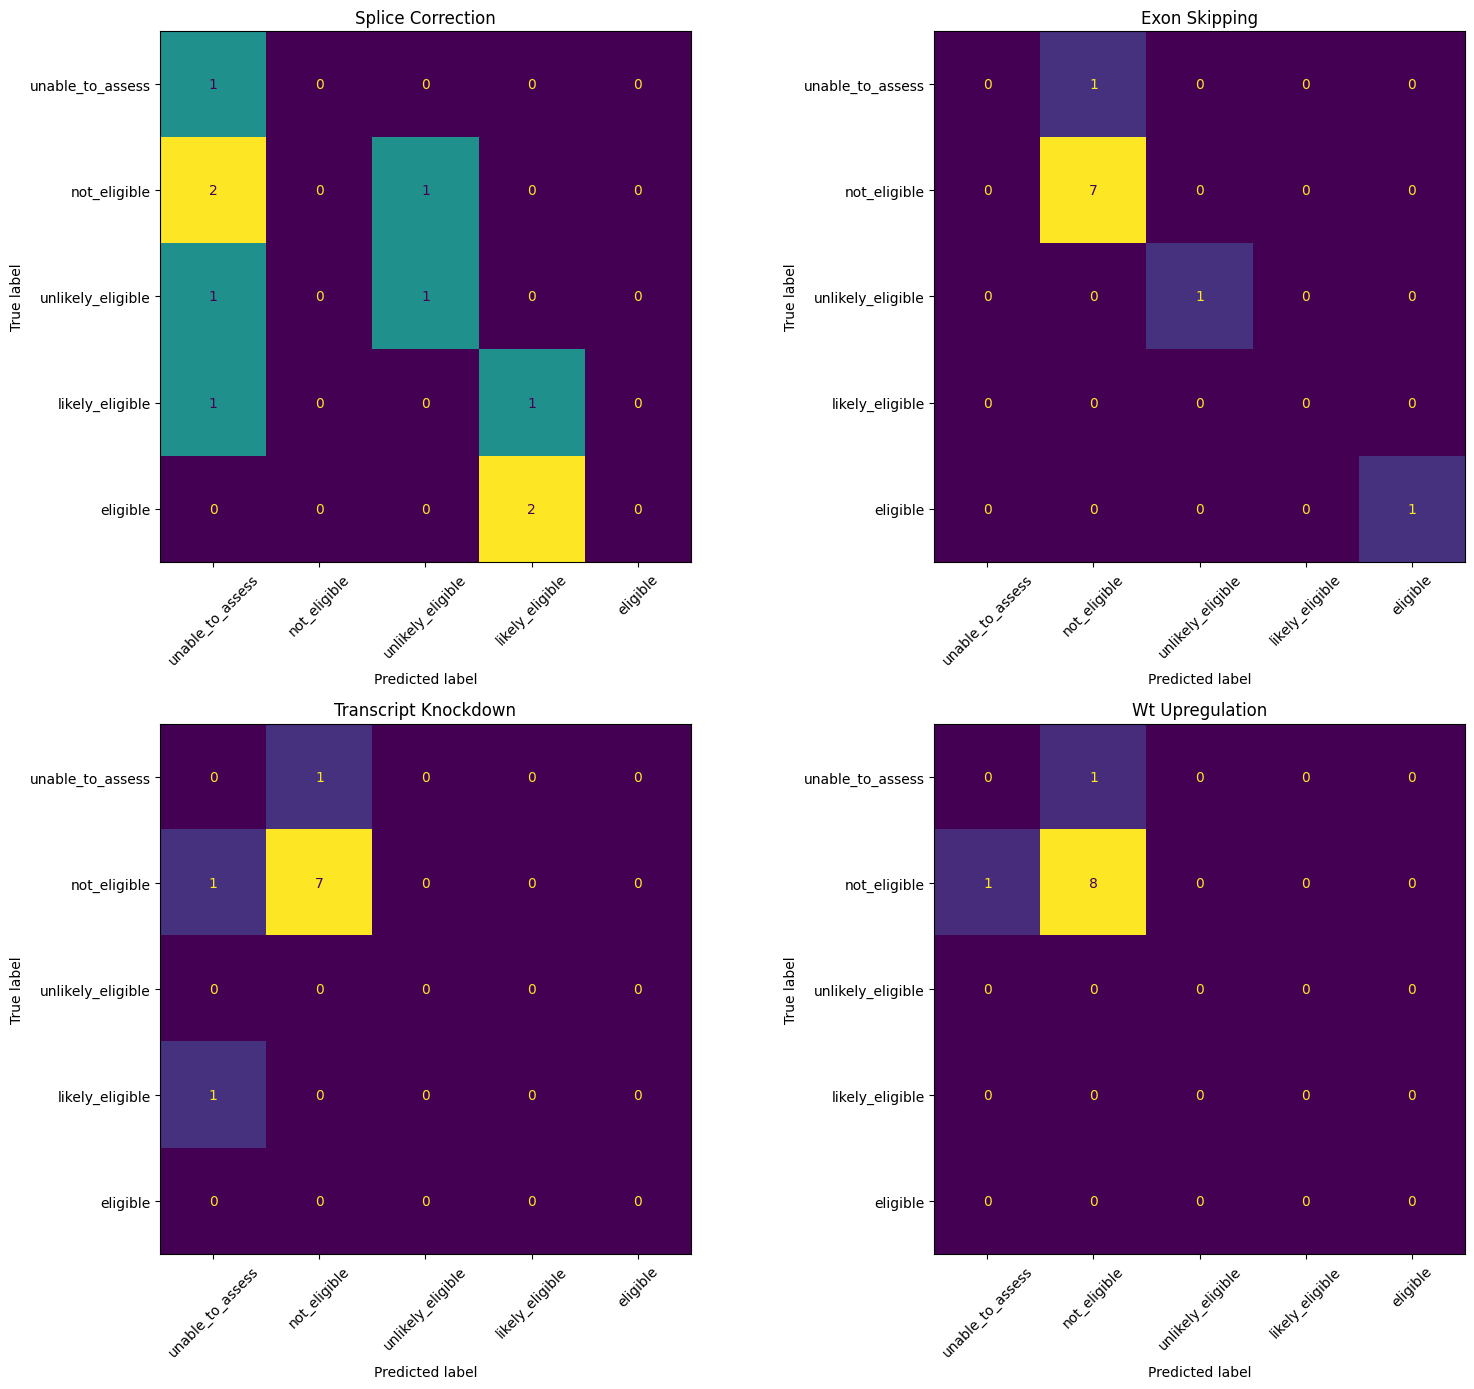

In [9]:
print(f"total examples: {len(labels_df)}")
print(f"total examples without error: {len(labels_df.loc[~labels_df["failed"]])}")

plot_df = labels_df.loc[~labels_df["failed"]]
plot_df = plot_df.map(lambda x: {"not_applicable": "not_eligible"}.get(x, x))
plot_confusion_matrices(plot_df)

In [9]:
approach = "splice_correction"
plot_df.loc[plot_df[f"pred_{approach}"] != plot_df[f"actual_{approach}"]][["hgvs", f"pred_{approach}", f"actual_{approach}"]]

,hgvs,pred_splice_correction,actual_splice_correction
0,NM_000329.3:c.1430A>G,unable_to_assess,likely_eligible
2,NM_000391.4:c.225A>G,unlikely_eligible,not_eligible
3,NM_018075.5:c.289del,unable_to_assess,not_eligible
4,NM_206933.4:c.2692C>T,unable_to_assess,not_eligible
